# Clustering of all data

Read in all necessary packages:

In [1]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pandas.io.parsers import read_csv
import scanpy as sc
import numpy as np
from functools import reduce
from anndata import AnnData, read_h5ad
import loompy
import collections
import scipy
import math
from matplotlib.colors import LinearSegmentedColormap
import random
from sklearn.mixture import GaussianMixture
from scipy.stats import poisson

import scipy
import tqdm
from statsmodels.stats.multitest import multipletests
import matplotlib.patches as mpatches

/var/folders/pb/hvc2shb53x194_v0c3h_jyccsf3dhb/T/ipykernel_5281/284414565.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


OMP: Info #273: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [2]:
sc.set_figure_params(dpi = 80)
sns.set_style("white")
sns.set_context("talk")
sns.set_style("ticks")

# Load the dataset

In [185]:
for_venn = pd.read_csv('../data/mouse_allex_TRiso_K4_state_allpb.csv')

In [189]:
for_venn_filtered = for_venn[for_venn['gau_state_log10'] == 1]

In [198]:
venn_diagram = pd.DataFrame(for_venn_filtered['name'].str.split(':', 
                                                 expand=True)).rename(columns={0:'gene',
                                                                               1:'promoter'})

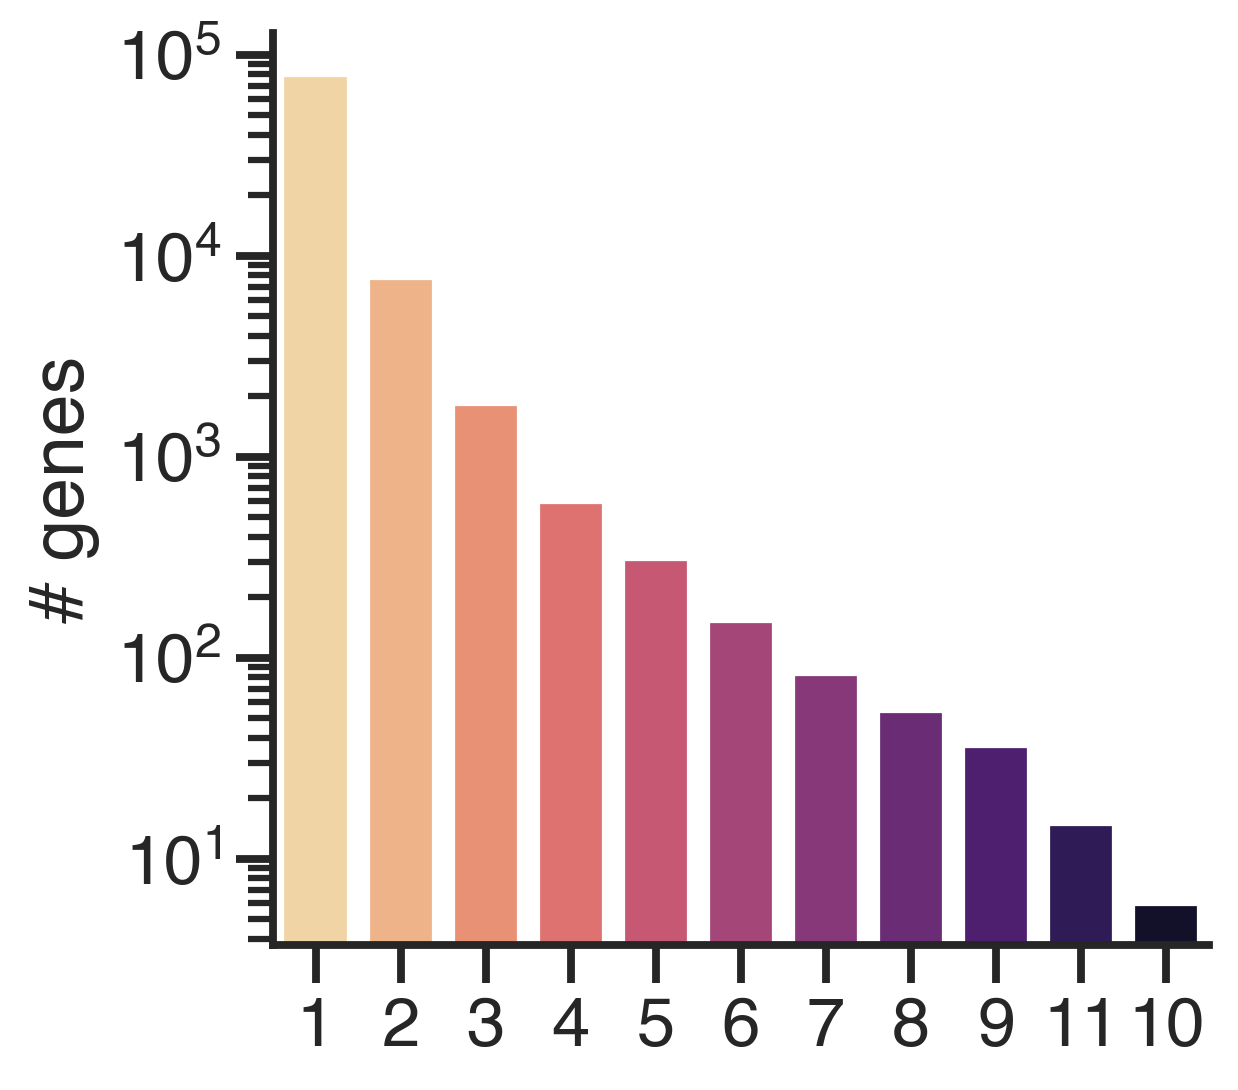

In [264]:
vals = pd.DataFrame(venn_diagram['promoter'].value_counts())

sns.barplot(x = vals.index, y = vals['promoter'], palette = 'magma_r', )
sns.despine()
plt.ylabel('# genes')           
plt.yscale('log')
plt.legend([],frameon=False)

In [286]:
for_venn_filtered[for_venn_filtered['variable'] == 'ESCs']

,name,biotype,gene,prom_type,prom_num_an,variable,value,value_log2,value_log10,gau_state_log10
0,Kitl:1,protein_coding,Kitl,main_an,2,ESCs,154.0,7.276124,2.190332,1
10,Tmtc3:1,protein_coding,Tmtc3,main_an,1,ESCs,214.0,7.748193,2.332438,1
11,Cep290:1,protein_coding,Cep290,main_an,6,ESCs,208.0,7.707359,2.320146,1
18,4930430F08Rik:1,protein_coding,4930430F08Rik,main_an,1,ESCs,105.0,6.727920,2.025306,1
19,1700017N19Rik:1,protein_coding,1700017N19Rik,main_an,2,ESCs,101.0,6.672425,2.008600,1
...,...,...,...,...,...,...,...,...,...,...
50021,Efnb1:1,protein_coding,Efnb1,main_an,1,ESCs,67.0,6.087463,1.832509,1
50024,Gm14808:1,lncRNA,Gm14808,main_an,1,ESCs,63.0,6.000000,1.806180,1
50025,Pja1:1,protein_coding,Pja1,main_an,1,ESCs,86.0,6.442943,1.939519,1
50026,Tmem28:1,protein_coding,Tmem28,main_an,1,ESCs,79.0,6.321928,1.903090,1


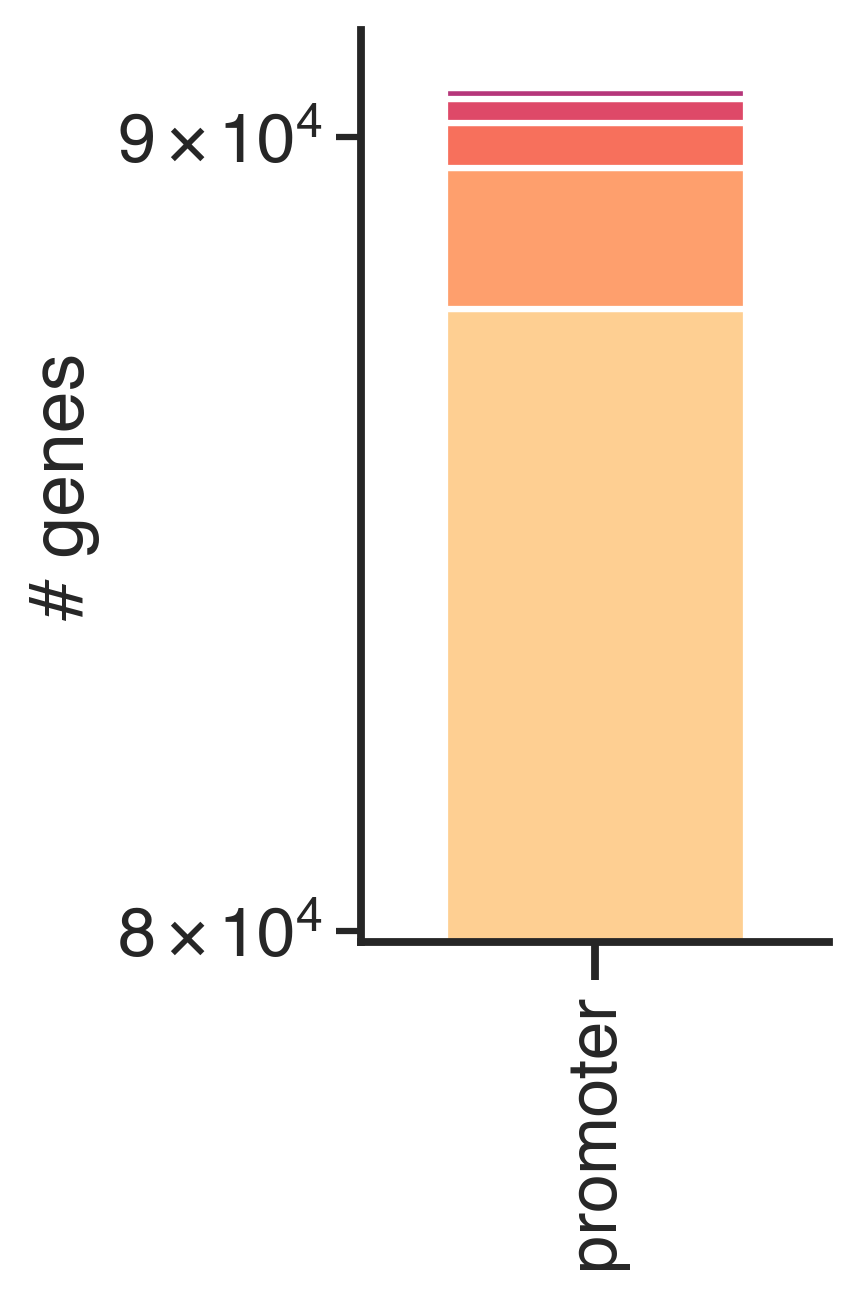

In [266]:
vals.T.plot.bar(stacked=True,width = 0.9, figsize = (2,4),
                cmap = 'magma_r')
plt.yscale('log')
plt.ylabel('# genes')
plt.legend([],frameon=False)
sns.despine()

In [218]:
sc.set_figure_params(dpi = 150)
sns.set_style("white")
sns.set_context("talk")
sns.set_style("ticks")

from matplotlib_venn import venn2, venn2_circles, venn2_unweighted
from matplotlib_venn import venn3, venn3_circles

font1 = {'family':'helvetica','color':'black','size':16} # use for title
font2 = {'family': 'helvetica', 'size': 8.5} # use for labels
plt.rc('font', **font2) # sets the default font 
plt.rcParams['text.color'] = 'black' # changes default text colour


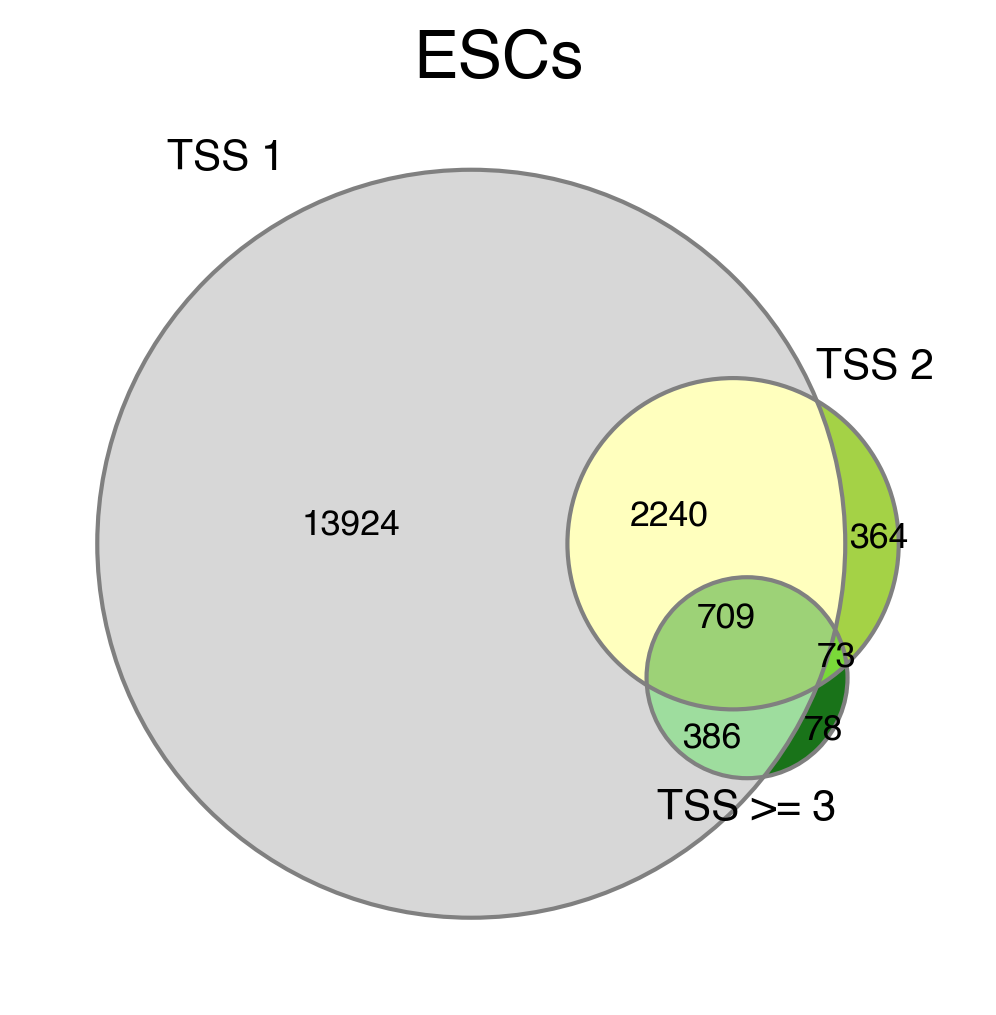

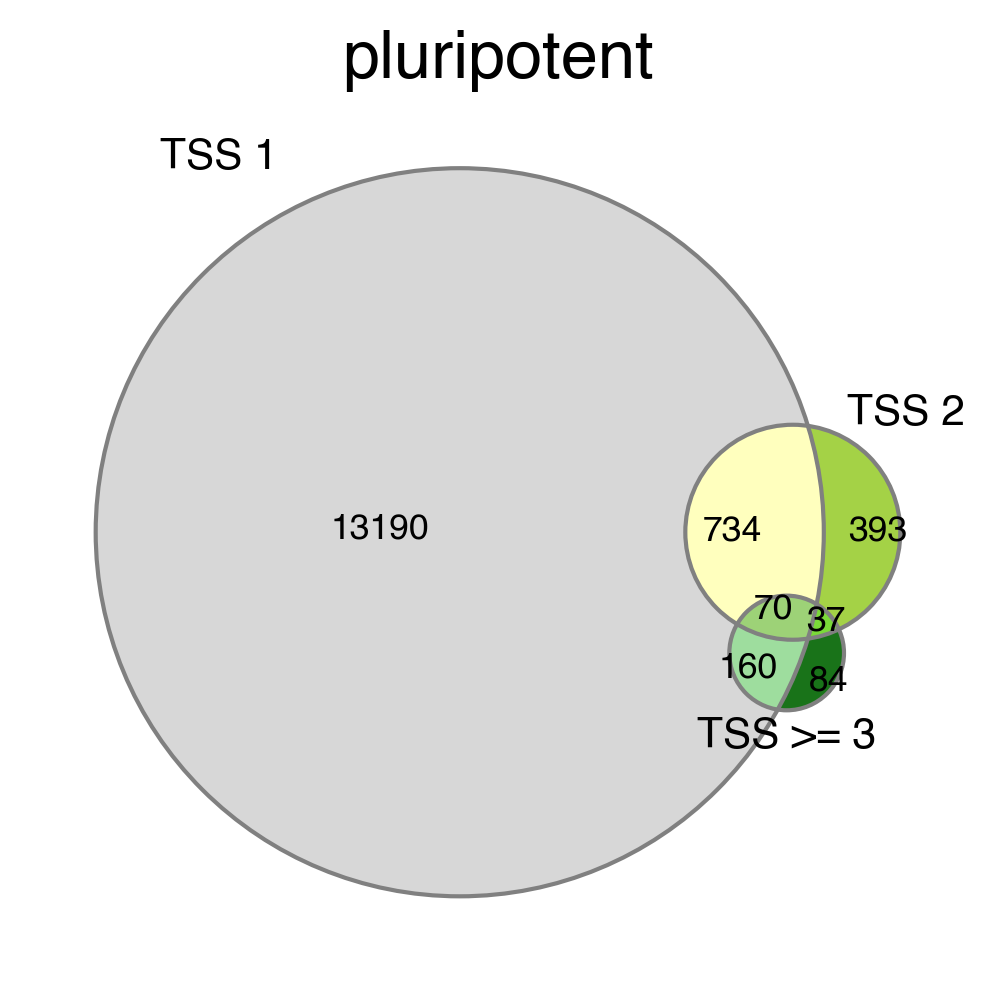

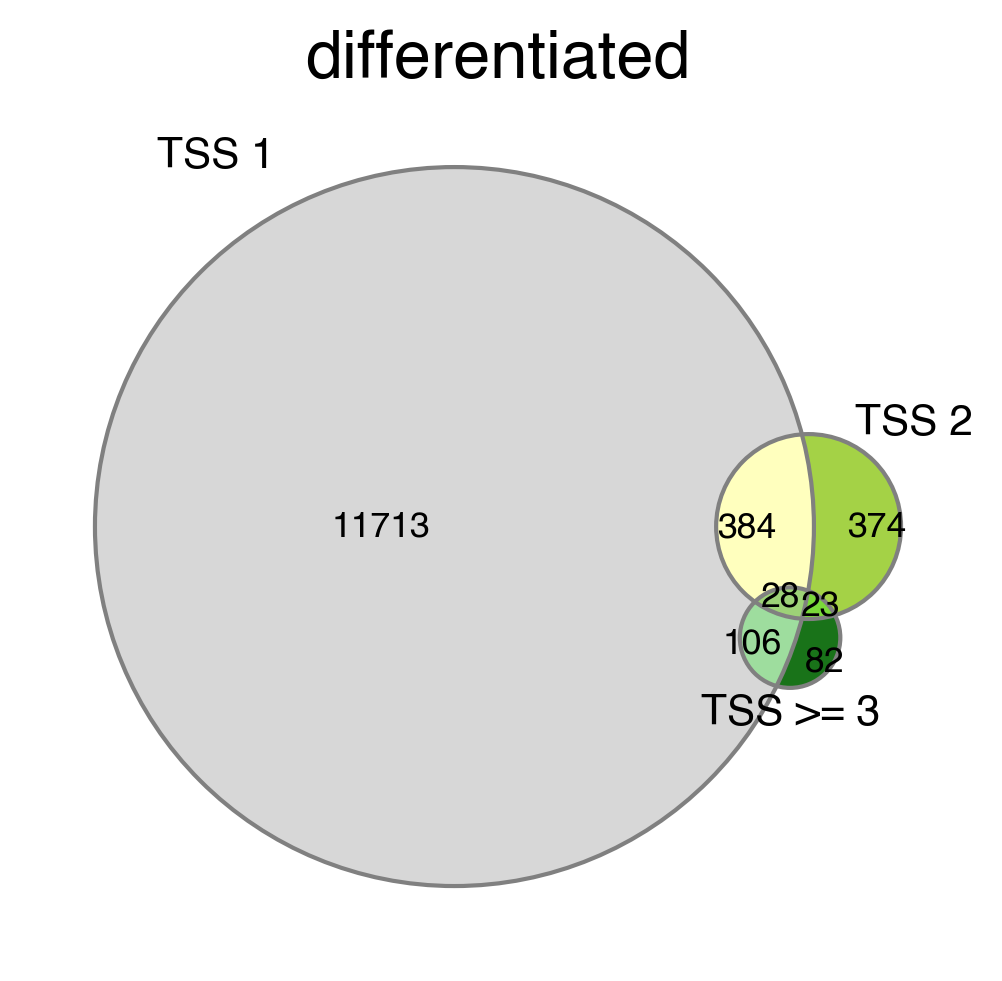

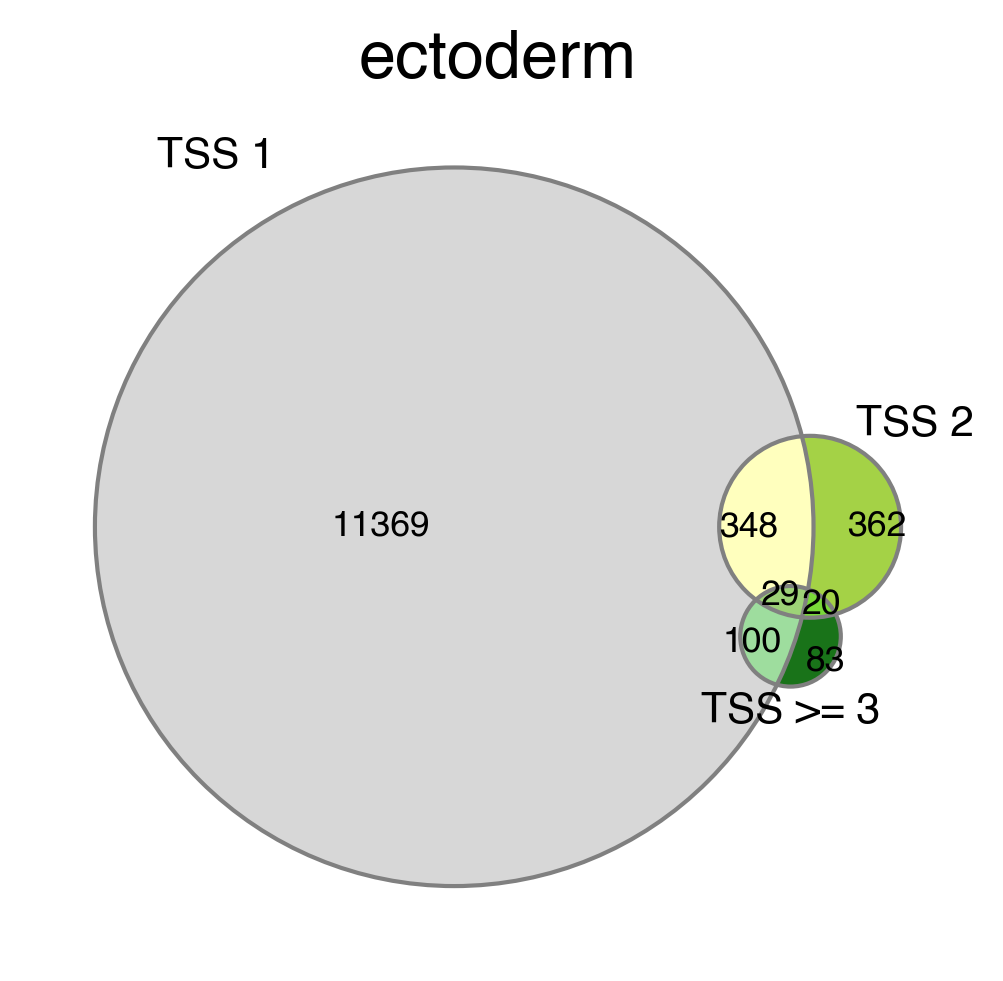

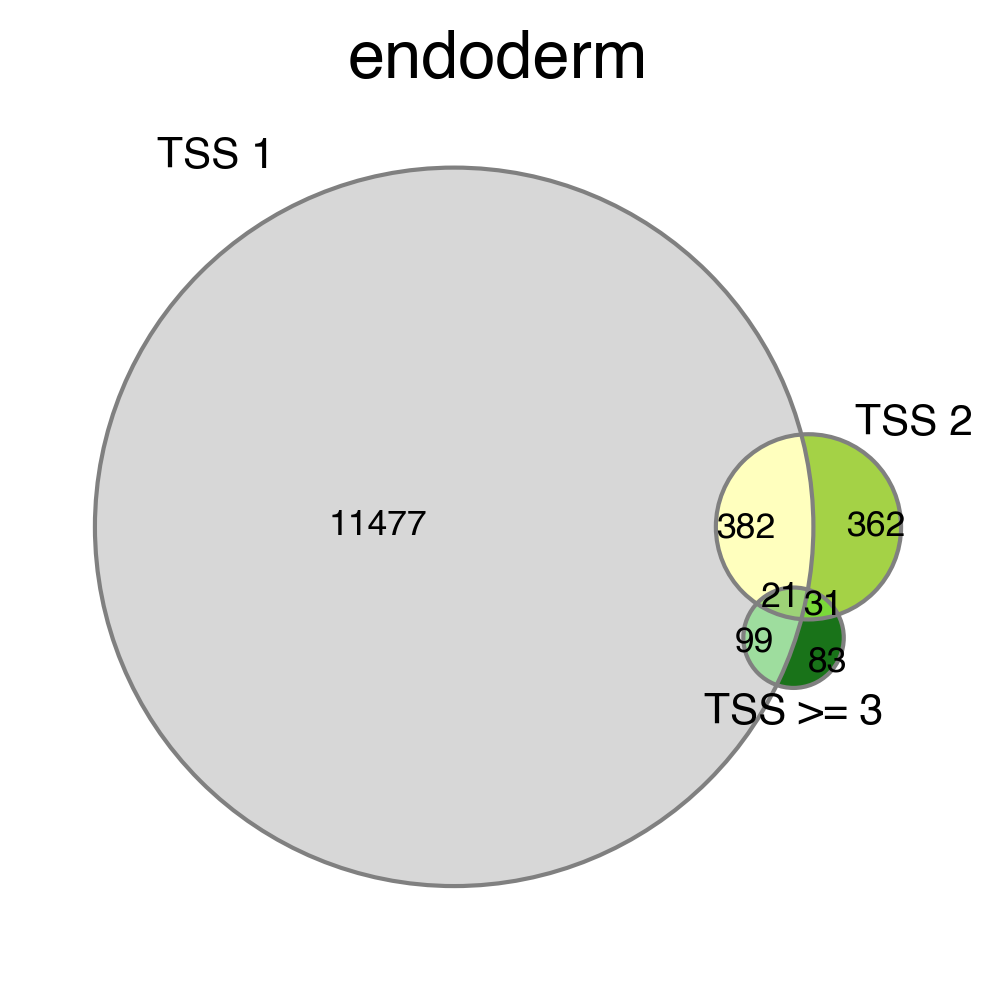

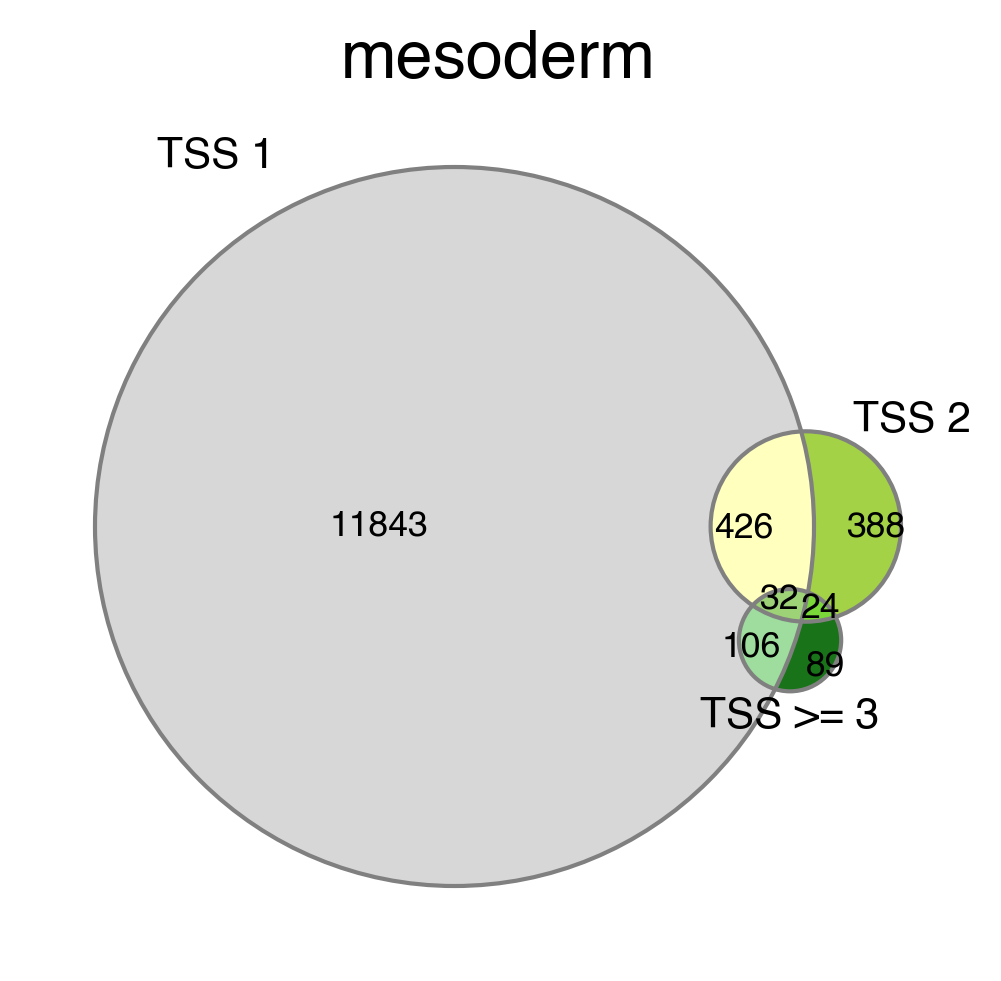

In [298]:
for ct in for_venn_filtered['variable'].unique():
    venn_ct = for_venn_filtered[for_venn_filtered['variable'] == ct]
    venn_diagram = pd.DataFrame(venn_ct['name'].str.split(':', 
                                                 expand=True)).rename(columns={0:'gene',
                                                                               1:'promoter'})
    a = list(venn_diagram[venn_diagram['promoter'] == '1']['gene'])
    b = list(venn_diagram[venn_diagram['promoter'] == '2']['gene'])
    c = list(venn_diagram[(venn_diagram['promoter'] != '1') & (venn_diagram['promoter'] != '2') ]['gene'])



    venn3([set(a),set(b),set(c)], set_labels = ('TSS 1','TSS 2','TSS >= 3'),
          set_colors=['lightgrey','yellowgreen','darkgreen'], alpha = 0.9,)
    venn3_circles([set(a),set(b),set(c)], linestyle = 'solid',linewidth = 1, color = 'grey')
    plt.title(ct, fontdict=font1)
    plt.show()



    
    